# Objetivo : Vamos a crear una LSTM donde vamos a clasificar si una novela es de Benito Pérez Galdós o bien de Emilia Pardo Bazán

Guíon del ejercicio

1. Importar las Librerías

2. Descargar las Novelas

3. Preparar el texto (250 palabras)

4. Crearemos el DataFrame

5. 80% Entrenamiento y 20% Test

6. Tokenizar

7. Padding

8. Configuraremos los hiperparámetros

9. Probaremos que funciona

10. Creamos una LSTM

11. Compile, fit.

12. Dibujaremos

13. Predecir como bien analiza nuestro modelo si son de Benito o de Emilia


In [ ]:
URLS = [
    ("galdos", "http://www.gutenberg.org/cache/epub/52392/pg52392.txt"),  # Miau
    ("galdos", "http://www.gutenberg.org/cache/epub/15725/pg15725.txt"),  # Doña Perfecta
    ("galdos", "http://www.gutenberg.org/cache/epub/17013/pg17013.txt"),  # Fortunata y Jacinta
    ("bazan", "https://www.gutenberg.org/files/65632/65632-0.txt"),  # La prueba
    ("bazan", "https://www.gutenberg.org/files/58059/58059-0.txt"),  # La Madre Naturaleza
    ("bazan", "https://www.gutenberg.org/cache/epub/17491/pg17491.txt"),  # La Tribuna
]

In [ ]:
# 1. Importar las Librerías

!pip install requests

import csv
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests  # <--- Corregido: agregado la 's'
from tqdm import tqdm
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM

In [ ]:
# 2. Descargar las novelas.
# Lo asignamos a una variable que sea galdos o bazan, lo vamos concatenando

galdos = ""

bazan = ""

for author, url in tqdm (URLS):
  texto = requests.get(url).text
  empieza = "START OF"
  acaba = "END OF"

  texto = texto[texto.index(empieza) : texto.index(acaba)]

  if author == "galdos":
    galdos += "\n " + texto
  else:
    bazan += "\n " + texto

100%|██████████| 6/6 [00:28<00:00,  4.77s/it]


In [ ]:
# 3. Preparar el texto (250 palabras).
n = 250
galdos_split = galdos.split()
trocitos_galdos = [galdos_split[i:i + n] for i in range(0, len(galdos_split),n)]
print(f"\nTrozos de galdós: {len(trocitos_galdos)} en bloques de {n}")
print(f"Ejemplo primer trozo: {trocitos_galdos[0]}")
print(f"Último trozo: {trocitos_galdos[-1]}")

bazan_split = bazan.split()
trocitos_bazan = [bazan_split[i:i + n] for i in range(0, len(bazan_split),n)]
print(f"\nTrozos de bazán: {len(trocitos_bazan)} en bloques de {n}")
print(f"Ejemplo primer trozo: {trocitos_bazan[0]}")
print(f"Último trozo: {trocitos_bazan[-1]}")


Trozos de galdós: 2425 en bloques de 250
Ejemplo primer trozo: ['START', 'OF', 'THE', 'PROJECT', 'GUTENBERG', 'EBOOK', 'MIAU', '***', 'MIAU', 'Es', 'propiedad.', 'Queda', 'hecho', 'el', 'depósito', 'que', 'marca', 'la', 'ley.', 'Serán', 'furtivos', 'los', 'ejemplares', 'que', 'no', 'lleven', 'el', 'sello', 'del', 'autor.', 'MIAU', 'POR', 'B.', 'PÉREZ', 'GALDÓS', '14.000', 'MADRID', 'LIBRERÍA', 'DE', 'PERLADO,', 'PÁEZ', 'Y', 'C.^{A}', '(Sucesores', 'de', 'Hernando)', 'Arenal,', 'núm,', '11.', '1907', 'Imprenta', 'de', 'los', 'Sucesores', 'de', 'Hernando,', 'Quintana,', '33.', 'MIAU', 'I', 'Á', 'las', 'cuatro', 'de', 'la', 'tarde,', 'la', 'chiquillería', 'de', 'la', 'escuela', 'pública', 'de', 'la', 'plazuela', 'del', 'Limón', 'salió', 'atropelladamente', 'de', 'clase,', 'con', 'algazara', 'de', 'mil', 'demonios.', 'Ningún', 'himno', 'á', 'la', 'libertad,', 'entre', 'los', 'muchos', 'que', 'se', 'han', 'compuesto', 'en', 'las', 'diferentes', 'naciones,', 'es', 'tan', 'hermoso', 'como', 

In [ ]:
# Preguntita

# ¿Quién hacía las novelas más largas?

galdos_longitud = len(trocitos_galdos)
bazan_longitud = len(trocitos_bazan)

galdos_longitud, bazan_longitud

(2425, 868)

In [ ]:
# Vamos a crearnos un dataframe

# Ejemplo

trocitos = ["Esto es el primer trozo" , "seguido del segundo", "y aqui terminamos"]

texto_unido = " ".join(trocitos)
texto_unido

'Esto es el primer trozo seguido del segundo y aqui terminamos'

In [ ]:
# 4. Crearemos el dataframe.

# sample(fra=1) lo hace aleatoriamente
# reset_index(drop=True)

def preparar_dataframe (text_chucks, label):
  df = pd.DataFrame([" ".join(chunk) for chunk in text_chucks], columns = ["text"])
  df = df.assign(label = label)
  df = df.sample(frac=1).reset_index(drop=True)

  return df

galdos_df = preparar_dataframe(trocitos_galdos, label = 1)
bazan_df = preparar_dataframe(trocitos_bazan, label = 0)


galdos_df.head()

,text,label
0,echo; =de menos---- = that make less noise. =e...,1
1,a mi padre el 48 unos desalmados partidarios. ...,1
2,la ropa delante y el gato muy repantigado en u...,1
3,"ver el disco, que le parecía el ojo de un bufó...",1
4,"en los ataques fuertes de su sobrino, Balleste...",1


In [ ]:
#Concatenar nuestros dos dataframes

train_df = pd.concat(
    [galdos_df[:int(galdos_longitud*.8)],
     bazan_df[:int(bazan_longitud*.8)]],
    ignore_index=True).sample(frac=1).reset_index(drop=True)

train_df.head()


# 5. 80% entrenamiento, 20% test.

#Pues vamos a por del Test -> Empezamos en el 80% y cogemos hasta el final

test_df = pd.concat(
    [galdos_df[int(galdos_longitud*.8):], bazan_df[int(bazan_longitud*.8):]],
    ignore_index=True
).sample(frac=1).reset_index(drop=True)

test_df

,text,label
0,echarle la sonda á un alma y ver lo que tiene ...,0
1,ella con la boca atarugada de brona--siquiera ...,0
2,han dado cien puñaladas... Pero estás viva. Cu...,1
3,gran plenitud de su corazón y el rosado vapor ...,0
4,"Pablo no había llegado aún, y decidió esperarl...",1
...,...,...
654,levantó y andando lentamente retirose a la hab...,1
655,"puerta. En aquel acto, todo lo que constituye ...",1
656,II. Barbarita I había concebido el loco proyec...,1
657,"que uno quisiera, y me tienes aquí secándome l...",1


In [ ]:
# ¿Cuántos registros tenemos de cada uno en los distintos datasets?

train_df.value_counts("label")

,count
label,
1,1940
0,694


1. **vocab_size** => como de largo queremos que sea. que pasa si es muy largo? lentooooo y si es muy pequeño, muchas palabras que desconoce
2. **max_length** => Tamaño de la secuencia
3. **embedding_dim** => Dimensión del vector de embeddings
4. **oov_tok** => Out of vocabulary
5. **trunc_type** => Donde voy a cortar
6. **padding_type**=> Rellenar

In [ ]:
# 6. Tokenizar.
vocab_size = 5000
max_length = 250
embedding_dim = 64
oov_tok = "<OOV>"
trunc_type = 'post'
padding_type = 'post'

####################

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok, lower=True)
tokenizer.fit_on_texts(train_df.text)

word_index = tokenizer.word_index



In [ ]:
# Ver las 10 primeras palabras

dict(list(word_index.items())[0:10])

{'<OOV>': 1,
 'de': 2,
 'que': 3,
 'la': 4,
 'y': 5,
 'el': 6,
 'a': 7,
 'en': 8,
 'no': 9,
 'se': 10}

In [ ]:
# Vamos a Tokenizar nuestro dataset

train_sequences = tokenizer.texts_to_sequences(train_df.text)

train_articles = train_df['text'].to_list()

In [ ]:
train_articles[0]

'la conducta política y privada de mi tío. Por allí cerca andaba el director de _El Teucrense_, que replicó de manera insultante, diciendo que al menos el mobiliario de mi tío no era adquirido por ninguna corporación, y disparando luego contra el mismo Requenita, con alusiones a los fondos de cierta suscripción, que habían dado fondo en el fondo del bolsillo del redactor de _La Aurora_. La disputa paró en una especie de reto. «Ahí fuera me lo dirá usted, si quiere», contestó Requenita a la provocación más directa de su adversario. Intervinimos, les calmamos, y al parecer quedó arreglado todo. A eso de las cinco de la madrugada, que es tanto como decir que era día claro, salíamos juntos del Casino el director de _El Teucrense_ y yo. Habíamos cenado, y aturdidos por el sueño y unas copas de detestable seudo-Champaña, mirábamos con sorpresa, parpadeando la luz solar, cuando al poner el pie en la calle se arrojaron sobre nosotros cuatro o cinco individuos, vociferando interjecciones. Eran 

In [ ]:
# 7. Padding.

train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [ ]:
# OJO !! El Dataset de Test es muy envidioso

test_sequences = tokenizer.texts_to_sequences(test_df.text)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [ ]:
print('Train shape:', train_padded.shape)
print('Test shape: ', test_padded.shape)

Train shape: (2634, 250)
Test shape:  (659, 250)


In [ ]:
# 8. Configuraremos los hiperparámetros.


In [ ]:
# 9. Probaremos que funciona.


In [ ]:
# 10. Crear LSTM.


In [ ]:
# Crear nuestro lego

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(embedding_dim)),
    tf.keras.layers.Dense(embedding_dim, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 11. Compilamos y entrenamos.


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history = model.fit(train_padded, train_df.label, epochs=20, validation_data=(test_padded, test_df.label), verbose=2)

Epoch 1/20
83/83 - 6s - 69ms/step - accuracy: 0.7411 - loss: 0.5749 - val_accuracy: 0.8376 - val_loss: 0.3981
Epoch 2/20
83/83 - 2s - 22ms/step - accuracy: 0.8781 - loss: 0.3149 - val_accuracy: 0.9090 - val_loss: 0.3763
Epoch 3/20
83/83 - 2s - 28ms/step - accuracy: 0.9472 - loss: 0.1826 - val_accuracy: 0.9150 - val_loss: 0.3090
Epoch 4/20
83/83 - 2s - 20ms/step - accuracy: 0.9780 - loss: 0.0675 - val_accuracy: 0.9423 - val_loss: 0.2448
Epoch 5/20
83/83 - 2s - 20ms/step - accuracy: 0.9905 - loss: 0.0379 - val_accuracy: 0.9469 - val_loss: 0.1716
Epoch 6/20
83/83 - 2s - 20ms/step - accuracy: 0.9799 - loss: 0.0632 - val_accuracy: 0.9636 - val_loss: 0.1455
Epoch 7/20
83/83 - 2s - 20ms/step - accuracy: 0.9457 - loss: 0.1308 - val_accuracy: 0.9029 - val_loss: 0.3024
Epoch 8/20
83/83 - 2s - 21ms/step - accuracy: 0.9897 - loss: 0.0352 - val_accuracy: 0.9590 - val_loss: 0.1784
Epoch 9/20
83/83 - 2s - 22ms/step - accuracy: 0.9973 - loss: 0.0121 - val_accuracy: 0.9530 - val_loss: 0.1796
Epoch 10/2

In [ ]:
# 12. Dibujamos.


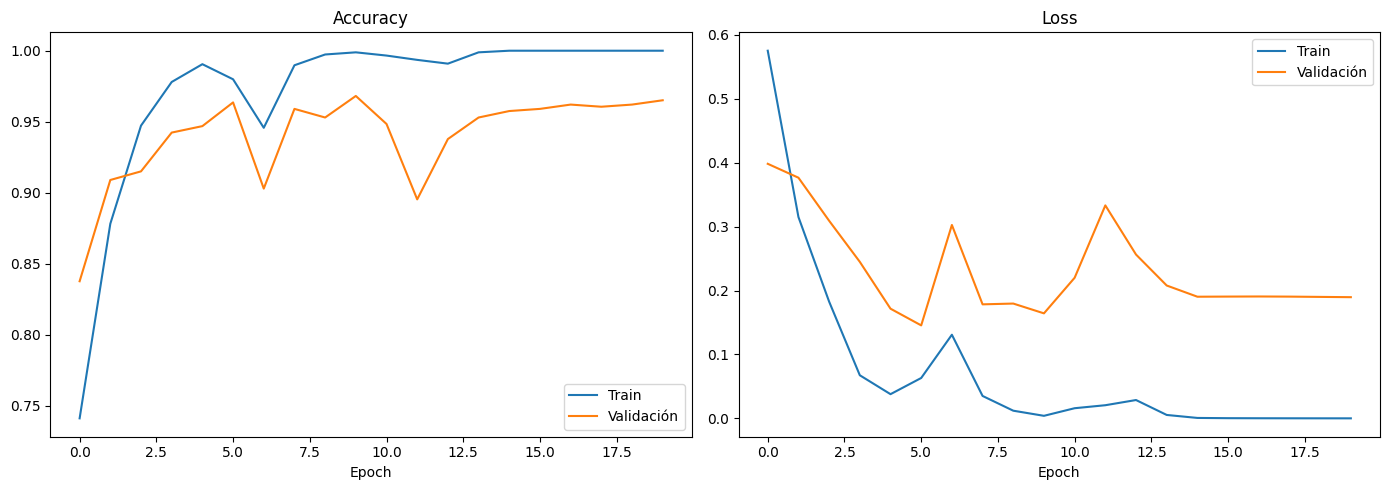

In [ ]:
# Ejercicio: Dibujar como ha ido el entrenamiento y la validación

def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validación')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validación')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
# 13. Predecir la fiabilidad del modelo, para saber si es de Benito o de Emilia.


In [ ]:
# Fragmento de Benito
txt = ['''
para que el triunfo fuese completo era menester que a Maxi le entrase una enfermedad asquerosa, repugnante y pestífera, de esas que ahuyentan hasta a los más allegados. Ella, entonces, daría pruebas de ser tan ángel como otra cualquiera, y tendría alma, paciencia, valor y estómago para todo. «Y entonces vería _esa_ si aquí hay perfecciones o no hay perfecciones, y que cada una es cada una... Lo malo sería que no lo viese, porque acá no ha de venir...». Maximiliano la distrajo de esta meditación, dando quejidos profundos. Ya conocía aquello su mujer y sabía el remedio, que era volverlo suavemente del otro lado... «¡Qué sueño!--murmuró Maxi medio despierto--. Soñaba que te habías marchado... y yo te había cogido de un pie, y tú tirabas, y yo tiraba más, y tirando se me rompía la bolsa del aneurisma, y todo el cuarto se llenaba de sangre, todo el cuarto, hasta el techo...». Le arrulló para que se durmiera, y ella se durmió también. Levantose temprano porque tenía que trabajar. Después de las nueve, cuando entró en la alcoba a ver si a su marido se le ofrecía alguna cosa, este se estaba vistiendo, y en una disposición de ánimo muy distinta de la que tuviera la noche anterior. No sólo parecía recobrado de su debilidad, sino que estaba inquieto, ágil y como si acabara de tomar un excitante muy enérgico. En cuanto entró su mujer, se fue derecho a ella, abotonándose el cuello de la camisa, y en tono
''']

seq = tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

pred = model.predict(padded)

print(pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[0.9999391]]


In [ ]:
# Fragmento de Emilia
txt = [''' Por más que el jinete trataba de sofrenarlo agarrándose con todas sus fuerzas a la única rienda de cordel y susurrando palabritas calmantes y mansas, el peludo rocín seguía empeñándose en bajar la cuesta a un trote cochinero que descuadernaba los intestinos, cuando no a trancos desigualísimos de loco galope. Y era pendiente de veras aquel repecho del camino real de Santiago a Orense en términos que los viandantes, al pasarlo, sacudían la cabeza murmurando que tenía bastante más declive del no sé cuántos por ciento marcado por la ley, y que sin duda al llevar la carretera en semejante dirección, ya sabrían los ingenieros lo que se pescaban, y alguna quinta de personaje político, alguna influencia electoral de grueso calibre debía andar cerca. Iba el jinete colorado, no como un pimiento, sino como una fresa, encendimiento propio de personas linfáticas. Por ser joven y de miembros delicados, y por no tener pelo de barba, pareciera un niño, a no desmentir la presunción sus trazas sacerdotales. Aunque cubierto de amarillo polvo que levantaba el trote del jaco, bien se advertía que el traje del mozo era de paño negro liso, cortado con la flojedad y poca gracia que distingue a las prendas de ropa de seglar vestidas por clérigos. Los guantes, despellejados ya por la tosca brida, eran asimismo negros y nuevecitos, igual que el hongo, que llevaba calado hasta las cejas, por temor a que los zarandeos de la trotada se lo hiciesen saltar al suelo, que sería el mayor compromiso del mundo. Bajo el cuello del desairado levitín asomaba un dedo de alzacuello, bordado de cuentas de abalorio. Demostraba el jinete escasa maestría hípica: inclinado sobre el arzón, con las piernas encogidas y a dos dedos de salir despedido por las orejas, leíase en su rostro tanto miedo al cuartago como si fuese algún corcel indómito rebosando fiereza y bríos. Al acabarse el repecho, volvió el jaco a la sosegada andadura habitual, y pudo el jinete enderezarse sobre el aparejo redondo, cuya anchura inconmensurable le había descoyuntado los huesos todos de la región sacro-ilíaca. Respiró, quitóse el sombrero y recibió en la frente sudorosa el aire frío de la tarde. Caían ya oblicuamente los rayos del sol en los zarzales y setos, y un peón caminero, en mangas de camisa, pues tenía su chaqueta colocada sobre un mojón de granito, daba lánguidos azadonazos en las hierbecillas nacidas al borde de la cuneta. Tiró el jinete del ramal para detener a su cabalgadura, y ésta, que se había dejado en la cuesta abajo las ganas de trotar, paró inmediatamente. El peón alzó la cabeza, y la placa dorada de su sombrero relució un instante. ''']

seq = tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

pred = model.predict(padded)

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.00047343]]
